# Stage 8 — Classical Post-Processing

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `07_run_on_backend.ipynb`
**Next:** → `09_var_fidelity_check.ipynb`

---

Stage 7 produced histograms of bitstrings. A bank does not care about bitstrings — it cares about **losses**. This notebook performs the base paper's classical post-processing step (Sec. IV-C): every measured bitstring is split into a default indicator and a latent-factor value, scenario losses are accumulated, and the result is a discrete portfolio-loss PDF and CDF — the object from which Value at Risk is read in Stage 9.

## 1. What Is Post-Processing Here? (General Overview)

In the quantum credit-risk workflow the quantum circuit is a **sampler**: it produces correlated (latent factor, default) scenarios with the right joint probabilities. Turning those scenarios into risk numbers is ordinary classical bookkeeping, identical to what one would do with Monte Carlo samples:

1. read the scenario encoded in each bitstring,
2. assign it a loss,
3. aggregate probabilities of equal losses into a loss distribution,
4. accumulate that distribution into a CDF.

In the full QAE algorithm this step is replaced by amplitude estimation on a loss register; for the uncertainty-model circuit studied by the paper (and replicated here), the distribution is read out directly, which is exactly what the paper does.

## 2. Why We Do This

1. **It is the bridge from physics to finance.** A Hellinger fidelity on bitstrings is a physicist's number; a loss CDF and a VaR are what the credit-risk use case is about.
2. **It lets us check the model, not just the histogram.** From the counts we can recover, for every latent-factor bin, the **conditional default probability** $P(\text{default}\mid z)$ — and compare it directly with the Vasicek curve $\mathrm{PD}(z)$ of Stage 1. This tests whether the asset encoding of Stage 2 survives noise and retuning.
3. **It reproduces the paper's Fig. 10** — the CDF of total losses for $L = \$1000$, with $P(L \le 0) \approx 0.75$ and $P(L \le 1000) = 1$.

## 3. Where This Fits in the Project Pipeline

This is **Stage 8 of 9**.

- **Input:** `results/stage07_execution.json` (measured distributions for every variant and repetition), and the Stage-2 encoding parameters.
- **Output:** `results/stage08_postprocessing.json` — per variant: latent-factor marginal, default probability, conditional PD per $z$ bin, loss PDF, CDF, expected loss, VaR, CVaR (with repetition-level spread), plus three classical references.

## 4. The Procedure (base paper, Sec. IV-C)

With Qiskit's little-endian convention, the asset qubit (index $n$) is the **leftmost** character of a bitstring and the $n$ z-register qubits are the **rightmost** $n$ characters — exactly the layout the paper describes ("the leftmost bits encode default indicators and the rightmost bits represent the latent variable Z").

For an outcome $i$ with probability $p_i$:

$$
b = i \bmod 2^n \;\;(\text{latent-factor index}), \qquad d = \lfloor i / 2^n \rfloor \;\;(\text{default indicator}), \qquad z_b = -z_{\max} + \frac{2z_{\max}}{2^n - 1}\, b
$$

$$
P(Z = z_b) \mathrel{+}= p_i, \qquad \text{loss}_i = d \cdot \mathrm{LGD}, \qquad
P(\text{default} \mid z_b) = \frac{P(d=1, Z=z_b)}{P(Z=z_b)}.
$$

Identical losses are merged into a discrete PDF $\{(L_j, P(L_j))\}$; its running sum is the CDF, and
$\mathbb{E}[L] = \sum_j L_j P(L_j)$. With one asset and $\mathrm{LGD} = \$1000$ the loss can only be \$0 or \$1000, so the CDF has two steps — just as in the paper's Fig. 10.

**Classical references** (computed on the same grid, no quantum circuit involved):

| Reference | Joint distribution |
|---|---|
| `classical_discrete_grid` | $P(z_b)\cdot\mathrm{PD}(z_b)$ with the target Gaussian and the exact Vasicek PD — Stage 1 "Method A" |
| `classical_linearized_encoding` | same, but with $\sin^2(\tilde\alpha b + \tilde\beta)$ — what the circuit is *designed* to encode (Stage 2) |
| `classical_monte_carlo_continuous` | 2 000 000 continuous Monte Carlo draws — Stage 1 "Method B" |

## 5. Implementation

### 5.1 Loading Stage 7's measurements

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import postprocess_register
from src.postprocessing import decompose, credit_statistics, z_grid
from src.gci_model import pd_given_z, target_gaussian_histogram
from src.pipeline_io import load_stage_output, load_encoding_params, save_json, save_fig

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s7 = load_stage_output("stage07_execution.json")
enc = load_encoding_params()["register_adapted"]
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register: variants = {list(s7[f'{n}_qubit']['variants'])}")

2-qubit register: variants = ['ideal_noiseless', 'noisy_uncalibrated', 'uncalibrated_REM', '6A_grid_REM', '6B_auto_REM', '6B_auto_REM_ZNE']
3-qubit register: variants = ['ideal_noiseless', 'noisy_uncalibrated', 'uncalibrated_REM', '6A_grid_REM', '6B_auto_REM', '6B_auto_REM_ZNE']


### 5.2 Walking through the decomposition once, by hand

For the 2-qubit register and the noiseless reference distribution, every bitstring, how it is split, and what it contributes:

In [2]:
n = 2
p = np.array(s7[f"{n}_qubit"]["variants"]["ideal_noiseless"]["mean_probs"])
zg = z_grid(n)
print(f"{'bitstring':>9} | {'default bit':>11} | {'z bits':>6} | {'b':>2} | {'z_b':>6} | {'loss $':>7} | {'probability':>11}")
print("-" * 72)
for i, pi in enumerate(p):
    bits = format(i, f"0{n+1}b")
    b, d = i % 2 ** n, i // 2 ** n
    print(f"{bits:>9} | {d:>11} | {bits[1:]:>6} | {b:>2} | {zg[b]:>6.2f} | {d * C.LGD:>7} | {pi:>11.4f}")

st = credit_statistics(p, n)
print(f"\nP(Z = z_b)          = {np.round(st['z_marginal'], 4)}")
print(f"P(default | z_b)    = {np.round(st['conditional_pd'], 4)}")
print(f"marginal P(default) = {st['p_default']:.4f}   (baseline p0 = {C.P0})")
print(f"loss PDF            = {dict(zip(st['unique_losses'], np.round(st['pdf'], 4)))}")
print(f"loss CDF            = {dict(zip(st['unique_losses'], np.round(st['cdf'], 4)))}")
print(f"expected loss       = ${st['expected_loss']:.2f}")

bitstring | default bit | z bits |  b |    z_b |  loss $ | probability
------------------------------------------------------------------------
      000 |           0 |     00 |  0 |  -3.00 |       0 |      0.0052
      001 |           0 |     01 |  1 |  -1.00 |       0 |      0.3415
      010 |           0 |     10 |  2 |   1.00 |       0 |      0.3929
      011 |           0 |     11 |  3 |   3.00 |       0 |      0.0079
      100 |           1 |     00 |  0 |  -3.00 |    1000 |      0.0038
      101 |           1 |     01 |  1 |  -1.00 |    1000 |      0.1495
      110 |           1 |     10 |  2 |   1.00 |    1000 |      0.0982
      111 |           1 |     11 |  3 |   3.00 |    1000 |      0.0010

P(Z = z_b)          = [0.0089 0.491  0.4911 0.0089]
P(default | z_b)    = [0.4205 0.3045 0.1999 0.1128]
marginal P(default) = 0.2525   (baseline p0 = 0.25)
loss PDF            = {0: np.float64(0.7475), 1000: np.float64(0.2525)}
loss CDF            = {0: np.float64(0.7475), 1000: np.floa

### 5.3 Post-processing every variant and repetition

In [3]:
post = {}
for n in C.REGISTER_SIZES:
    post[n] = postprocess_register(n, s7[f"{n}_qubit"], enc[f"{n}_qubit"])
    print(f"=== {n}-qubit register ===")
    print(f"{'variant':34s} | {'P(default)':>16} | {'P(L<=0)':>7} | {'E[L] ($)':>15} | {'VaR95':>6}")
    rows = list(post[n]["variants"].items()) + [(k, v) for k, v in post[n]["classical"].items()
                                                  if k != "classical_monte_carlo_continuous"]
    for k, v in rows:
        pd_s = f"{v['p_default']:.4f}" + (f" +/- {v['p_default_std']:.4f}" if "p_default_std" in v else "")
        el_s = f"{v['expected_loss']:.1f}" + (f" +/- {v['expected_loss_std']:.1f}" if "expected_loss_std" in v else "")
        print(f"{k:34s} | {pd_s:>16} | {v['cdf'][0]:7.4f} | {el_s:>15} | {v['var']:6.0f}")
    mc = post[n]["classical"]["classical_monte_carlo_continuous"]
    print(f"{'classical_monte_carlo_continuous':34s} | {mc['p_default']:>16.4f} | {mc['cdf'][0]:7.4f} | "
          f"{mc['expected_loss']:>15.1f} | {mc['var']:6.0f}\n")

=== 2-qubit register ===
variant                            |       P(default) | P(L<=0) |        E[L] ($) |  VaR95
ideal_noiseless                    | 0.2525 +/- 0.0000 |  0.7475 |   252.5 +/- 0.0 |   1000
noisy_uncalibrated                 | 0.1741 +/- 0.0031 |  0.8259 |   174.1 +/- 3.1 |   1000
uncalibrated_REM                   | 0.1653 +/- 0.0034 |  0.8347 |   165.3 +/- 3.4 |   1000
6A_grid_REM                        | 0.2447 +/- 0.0028 |  0.7553 |   244.7 +/- 2.8 |   1000
6B_auto_REM                        | 0.2729 +/- 0.0035 |  0.7271 |   272.9 +/- 3.5 |   1000
6B_auto_REM_ZNE                    | 0.2581 +/- 0.0046 |  0.7419 |   258.1 +/- 4.6 |   1000
classical_discrete_grid            |           0.2504 |  0.7496 |           250.4 |   1000
classical_linearized_encoding      |           0.2525 |  0.7475 |           252.5 |   1000
classical_monte_carlo_continuous   |           0.2503 |  0.7497 |           250.3 |   1000



=== 3-qubit register ===
variant                            |       P(default) | P(L<=0) |        E[L] ($) |  VaR95
ideal_noiseless                    | 0.2544 +/- 0.0000 |  0.7456 |   254.4 +/- 0.0 |   1000
noisy_uncalibrated                 | 0.1907 +/- 0.0027 |  0.8093 |   190.7 +/- 2.7 |   1000
uncalibrated_REM                   | 0.1840 +/- 0.0029 |  0.8160 |   184.0 +/- 2.9 |   1000
6A_grid_REM                        | 0.2625 +/- 0.0021 |  0.7375 |   262.5 +/- 2.1 |   1000
6B_auto_REM                        | 0.2613 +/- 0.0036 |  0.7387 |   261.3 +/- 3.6 |   1000
6B_auto_REM_ZNE                    | 0.2299 +/- 0.0042 |  0.7701 |   229.9 +/- 4.2 |   1000
classical_discrete_grid            |           0.2500 |  0.7500 |           250.0 |   1000
classical_linearized_encoding      |           0.2522 |  0.7478 |           252.2 |   1000
classical_monte_carlo_continuous   |           0.2503 |  0.7497 |           250.3 |   1000



### 5.4 The latent factor: is the Gaussian still there after noise?

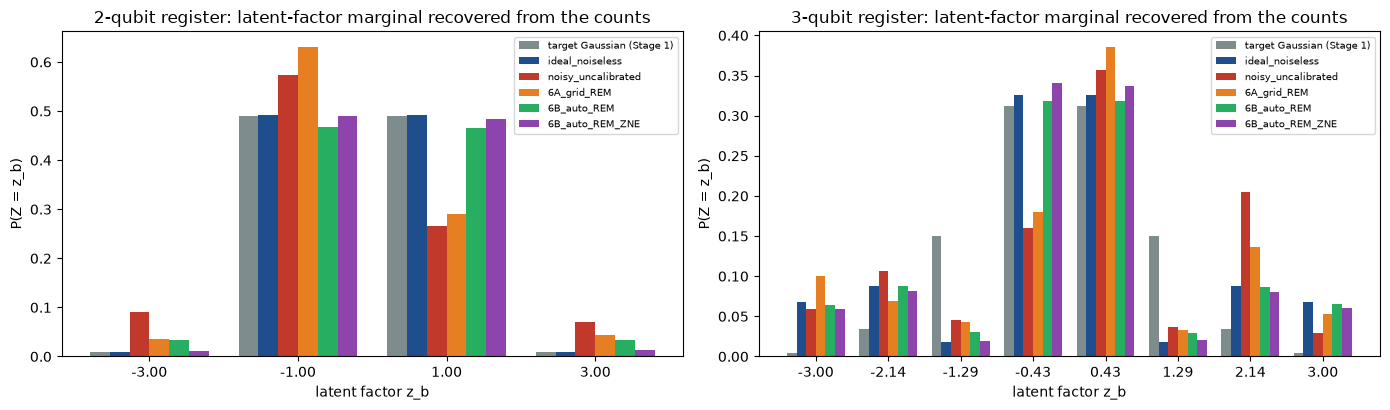

In [4]:
show = ["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    zg, target = target_gaussian_histogram(n, C.Z_MAX)
    w = 0.8 / (len(show) + 1)
    ax.bar(np.arange(2 ** n) - 0.4 + w / 2, target, w, color=GREY, label="target Gaussian (Stage 1)")
    for i, k in enumerate(show):
        ax.bar(np.arange(2 ** n) - 0.4 + (i + 1.5) * w, post[n]["variants"][k]["z_marginal"], w,
               color=COLORS[k], label=k)
    ax.set_xticks(range(2 ** n)); ax.set_xticklabels([f"{z:.2f}" for z in zg])
    ax.set_xlabel("latent factor z_b"); ax.set_ylabel("P(Z = z_b)")
    ax.set_title(f"{n}-qubit register: latent-factor marginal recovered from the counts")
    ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage08_latent_marginal.png"); plt.show()

### 5.5 The credit model: recovering PD(z) from the counts

For every latent-factor bin, the measured conditional default rate $P(\text{default}\mid z_b)$ against the classical Vasicek curve (Stage 1) and the $\sin^2$ encoding it was linearised into (Stage 2). This is the most direct test that the *financial model*, not just some histogram, survives the hardware. (Bins with very little probability mass — the tails of the 2-qubit grid — carry large statistical uncertainty.)

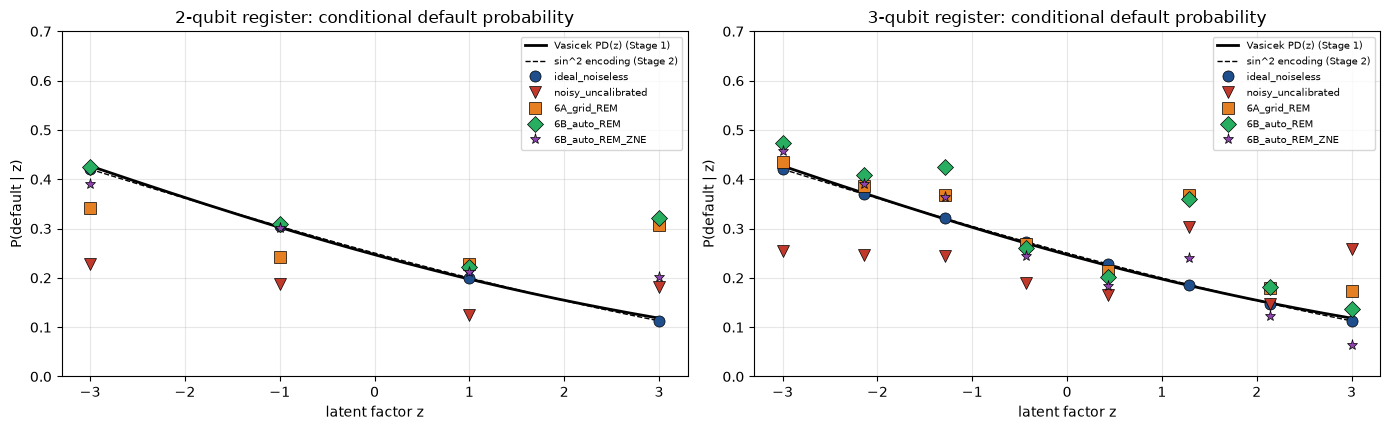

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, n in zip(axes, C.REGISTER_SIZES):
    zg = z_grid(n)
    zz = np.linspace(-C.Z_MAX, C.Z_MAX, 300)
    ax.plot(zz, pd_given_z(zz, C.P0, C.RHO), color="k", lw=2, label="Vasicek PD(z) (Stage 1)")
    a_t, b_t = enc[f"{n}_qubit"]["alpha_tilde"], enc[f"{n}_qubit"]["beta_tilde"]
    bb = (zz + C.Z_MAX) * (2 ** n - 1) / (2 * C.Z_MAX)
    ax.plot(zz, np.sin(a_t * bb + b_t) ** 2, color="k", ls="--", lw=1, label="sin^2 encoding (Stage 2)")
    for k, mk in zip(["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"],
                     ["o", "v", "s", "D", "*"]):
        ax.plot(zg, post[n]["variants"][k]["conditional_pd"], mk, color=COLORS[k], ms=8, mec="k", mew=0.5, label=k)
    ax.set_xlabel("latent factor z"); ax.set_ylabel("P(default | z)")
    ax.set_title(f"{n}-qubit register: conditional default probability")
    ax.set_ylim(0, 0.7); ax.grid(alpha=0.3); ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage08_conditional_pd.png"); plt.show()

### 5.6 Loss distribution and CDF — the paper's Fig. 10

Paper Fig. 10 shows (a) the simulated transpiled circuit, (b) the simulated hardware-ready circuit, (c) the hardware experiment. The equivalent panels here are the noiseless reference, the automated-calibration pipeline, and — for contrast — the uncalibrated circuit, each with the classical Monte Carlo CDF of Stage 1 overlaid.

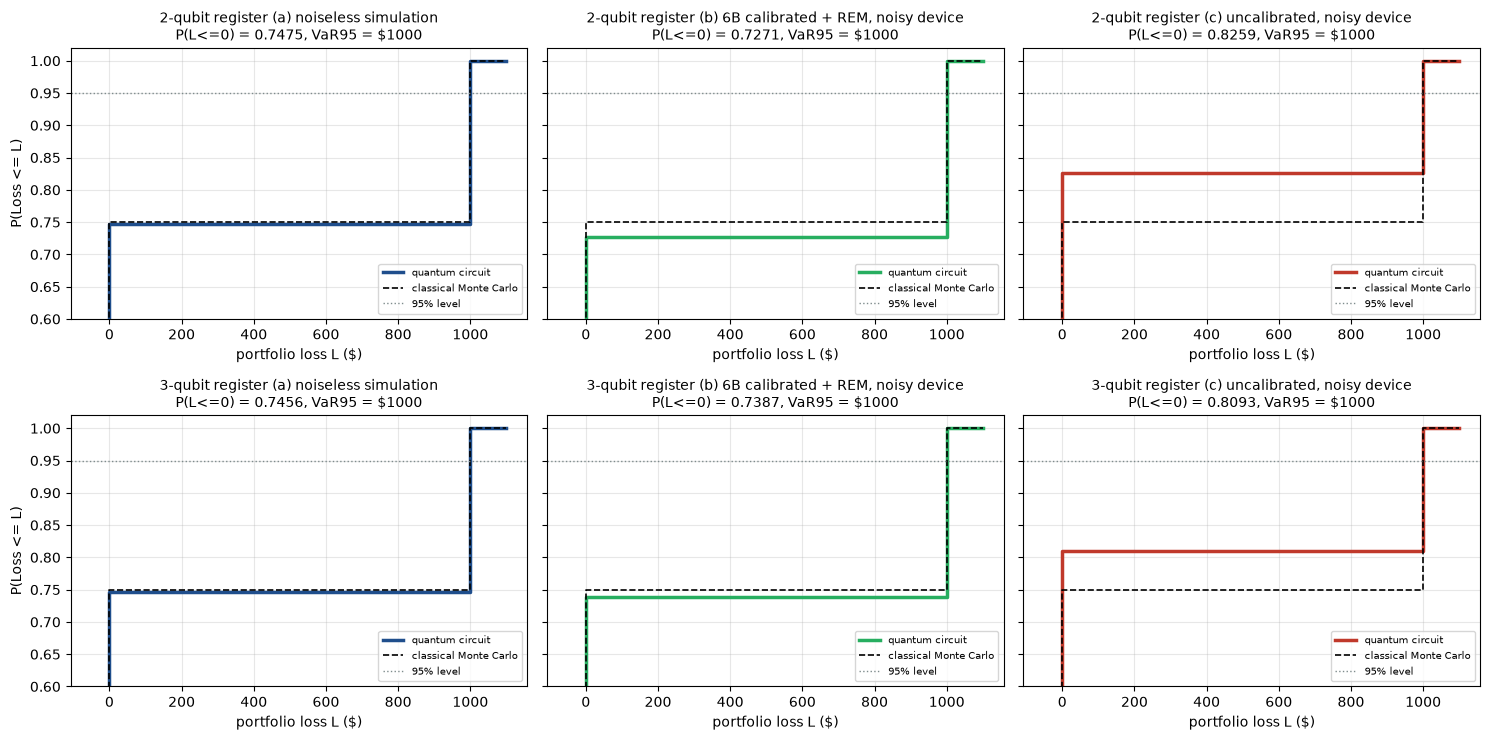

In [6]:
panels = [("ideal_noiseless", "(a) noiseless simulation"), ("6B_auto_REM", "(b) 6B calibrated + REM, noisy device"),
          ("noisy_uncalibrated", "(c) uncalibrated, noisy device")]
mc = post[2]["classical"]["classical_monte_carlo_continuous"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for r, n in enumerate(C.REGISTER_SIZES):
    for ax, (k, title) in zip(axes[r], panels):
        v = post[n]["variants"][k]
        L = np.array(v["unique_losses"]); cdf = np.array(v["cdf"])
        ax.step(np.r_[-50, L, 1100], np.r_[0, cdf, 1], where="post", color=COLORS[k], lw=2.5, label="quantum circuit")
        ax.step(np.r_[-50, mc["unique_losses"], 1100], np.r_[0, mc["cdf"], 1], where="post",
                color="k", ls="--", lw=1.2, label="classical Monte Carlo")
        ax.axhline(C.CONFIDENCE, color=GREY, ls=":", lw=1, label="95% level")
        ax.set_title(f"{n}-qubit register {title}\nP(L<=0) = {cdf[0]:.4f}, VaR95 = ${v['var']:.0f}", fontsize=10)
        ax.set_xlabel("portfolio loss L ($)"); ax.set_ylim(0.6, 1.02); ax.grid(alpha=0.3)
        if ax is axes[r][0]:
            ax.set_ylabel("P(Loss <= L)")
        ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage08_loss_cdf.png"); plt.show()

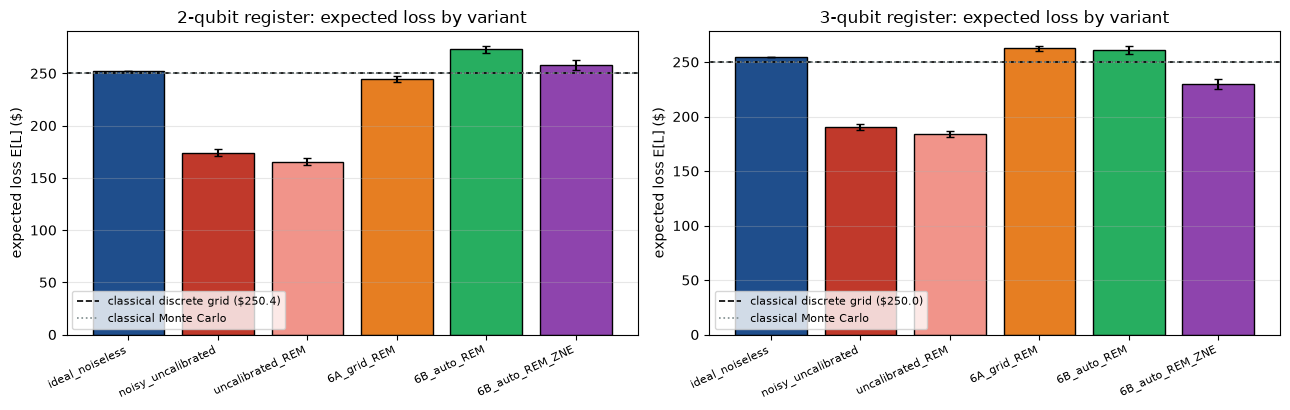

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
keys = list(post[2]["variants"])
for ax, n in zip(axes, C.REGISTER_SIZES):
    V = post[n]["variants"]
    el = [V[k]["expected_loss"] for k in keys]
    sd = [V[k]["expected_loss_std"] for k in keys]
    ax.bar(range(len(keys)), el, yerr=sd, capsize=3, color=[COLORS[k] for k in keys], edgecolor="k")
    cl = post[n]["classical"]["classical_discrete_grid"]["expected_loss"]
    ax.axhline(cl, color="k", ls="--", lw=1.2, label=f"classical discrete grid (${cl:.1f})")
    ax.axhline(post[n]["classical"]["classical_monte_carlo_continuous"]["expected_loss"], color=GREY, ls=":",
               lw=1.2, label="classical Monte Carlo")
    ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("expected loss E[L] ($)"); ax.set_title(f"{n}-qubit register: expected loss by variant")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig(fig, "stage08_expected_loss.png"); plt.show()

### 5.7 Reading the result

- The noiseless circuit gives $P(L \le 0) \approx 0.75$ and $P(L \le 1000) = 1$ — the same numbers as the base paper's Fig. 10.
- Without calibration the default probability is strongly biased downwards (the drift under-rotates the asset qubit): the expected loss is off by roughly \$60–80 — yet the 95% VaR is still \$1000. Stage 9 explains why VaR alone is a weak test here.
- After calibration + readout mitigation, $P(\text{default}\mid z)$ follows the Vasicek curve again in the bins that carry probability mass, and the expected loss is back within roughly ±10% of the reference.
- An honest subtlety: for the 2-qubit register the **6A** angles land slightly closer on expected loss than **6B**, although 6B has the clearly higher Hellinger fidelity (Stage 7). Fidelity over the joint distribution and one scalar marginal such as $P(\text{default})$ are different yardsticks; the calibration optimises the former. Adding the loss marginal to the calibration objective ("task-aware calibration") is a natural next step — listed in Stage 9's future work.
- ZNE shifts the default probability in opposite directions for the two registers, so on top of retuning it is not a reliable improvement for the *risk* numbers even when it raises the fidelity.

### 5.8 Saving for Stage 9

In [8]:
out = {f"{n}_qubit": post[n] for n in C.REGISTER_SIZES}
path = save_json(out, "stage08_postprocessing.json")
print(f"Saved -> {path}")

Saved -> /home/muthuraam/quantum-credit-risk-vqc/results/stage08_postprocessing.json


## 6. What This Stage Produces

1. **The base paper's post-processing, implemented generically** (`src/postprocessing.py`): bitstring → (default, latent factor) → scenario loss → PDF → CDF, plus expected loss, VaR and CVaR; written for any number of asset bits.
2. **A model-level check under noise** — the conditional default curve $P(\text{default}\mid z)$ recovered from the measurements and compared with the Vasicek formula.
3. **The reproduction of the paper's Fig. 10** for both register sizes, with the classical Monte Carlo CDF overlaid.
4. **`results/stage08_postprocessing.json`** — loss statistics for every variant, repetition and classical reference.

## 7. What's Next

**Stage 9 — VaR & fidelity check (`09_var_fidelity_check.ipynb`):** extract the 95% VaR, compute Hellinger fidelities against the noiseless reference and the classical GCI baseline, and run the ACCEPT / RE-CALIBRATE decision loop of the architecture diagram.

---
*Next: → `09_var_fidelity_check.ipynb`*